In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Product-Statistics-UPI-Product-statistics-upi-2016-17-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2016-17-Monthly.xlsx
Saving Product-Statistics-UPI-Product-statistics-upi-2017-18-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2017-18-Monthly.xlsx
Saving Product-Statistics-UPI-Product-statistics-upi-2018-19-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2018-19-Monthly.xlsx
Saving Product-Statistics-UPI-Product-statistics-upi-2019-20-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2019-20-Monthly.xlsx
Saving Product-Statistics-UPI-Product-statistics-upi-2020-21-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2020-21-Monthly.xlsx
Saving Product-Statistics-UPI-Product-statistics-upi-2021-22-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2021-22-Monthly.xlsx
Saving Product-Statistics-UPI-Product-statistics-upi-2022-23-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2022-23-Month

In [3]:
files_list = sorted(glob.glob('Product-Statistics-UPI-Product-statistics-upi-*.xlsx'))
print(len(files_list))
all_years = [pd.read_excel(f, sheet_name='Product Statistics') for f in files_list]
df = pd.concat(all_years, ignore_index=True)
print(df.shape)

11
(123, 4)


In [4]:
df['value_cr'] = df['Value (In Cr.)'].astype(str).str.strip().str.replace(',', '', regex=False).astype(float)
df['volume_mn'] = df['Volume (In Mn.)'].astype(str).str.strip().str.replace(',', '', regex=False).astype(float)
df['month_parsed'] = pd.to_datetime(df['Month'], format='%B-%Y')

clean_2021on = df[['month_parsed', 'volume_mn', 'value_cr']].rename(columns={'month_parsed': 'month'})
clean_2021on = clean_2021on.sort_values('month').reset_index(drop=True)
clean_2021on = clean_2021on[clean_2021on['month'] >= '2021-01-01'].reset_index(drop=True)

print("Duplicate months:", clean_2021on['month'].duplicated().sum())
print(clean_2021on.shape)

Duplicate months: 0
(66, 3)


In [5]:
ts = clean_2021on.set_index('month')['volume_mn']
ts = ts.asfreq('MS')

train = ts[:-6]
test  = ts[-6:]

print("Train range:", train.index.min(), "to", train.index.max())
print("Test range:", test.index.min(), "to", test.index.max())
print("Train size:", len(train), "months")

Train range: 2021-01-01 00:00:00 to 2025-12-01 00:00:00
Test range: 2026-01-01 00:00:00 to 2026-06-01 00:00:00
Train size: 60 months


In [6]:
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
fit = model.fit(disp=False)

forecast = fit.forecast(steps=6)

comparison = pd.DataFrame({'actual': test, 'forecast': forecast})
comparison['error_pct'] = ((comparison['forecast'] - comparison['actual']) / comparison['actual'] * 100).round(1)
print(comparison)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


              actual      forecast  error_pct
2026-01-01  21703.44  21778.547523        0.3
2026-02-01  20394.18  21104.591765        3.5
2026-03-01  22641.11  23128.698160        2.2
2026-04-01  22346.80  22758.671123        1.8
2026-05-01  23201.93  23543.425730        1.5
2026-06-01  22716.07  23280.676494        2.5


In [7]:
pred_in_sample = fit.predict(start=train.index[0], end=train.index[-1])
residuals = train - pred_in_sample
resid_z = (residuals - residuals.mean()) / residuals.std()

resid_z.to_csv('sarima_residuals.csv')
files.download('sarima_residuals.csv')

print(resid_z.sort_values().head(5))   # most negative = actual came in far BELOW expected

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

month
2022-01-01   -2.937260
2025-02-01   -1.720088
2024-11-01   -1.628843
2025-10-01   -1.612119
2023-02-01   -1.138847
dtype: float64


In [8]:
pred_in_sample = fit.predict(start=train.index[0], end=train.index[-1])
residuals = train - pred_in_sample
resid_z = (residuals - residuals.mean()) / residuals.std()

resid_z.to_csv('sarima_residuals.csv')
files.download('sarima_residuals.csv')

print(resid_z.sort_values().head(5))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

month
2022-01-01   -2.937260
2025-02-01   -1.720088
2024-11-01   -1.628843
2025-10-01   -1.612119
2023-02-01   -1.138847
dtype: float64


second run

In [9]:
# Alternative SARIMA order — simpler seasonal component (no seasonal AR, just seasonal MA)
model2 = SARIMAX(train, order=(0,1,1), seasonal_order=(0,1,1,12))
fit2 = model2.fit(disp=False)

forecast2 = fit2.forecast(steps=6)

comparison2 = pd.DataFrame({'actual': test, 'forecast': forecast2})
comparison2['error_pct'] = ((comparison2['forecast'] - comparison2['actual']) / comparison2['actual'] * 100).round(1)
print("Model 2: (0,1,1)x(0,1,1,12)")
print(comparison2)

print("\nModel 1 avg abs error:", comparison['error_pct'].abs().mean().round(2), "%")
print("Model 2 avg abs error:", comparison2['error_pct'].abs().mean().round(2), "%")

Model 2: (0,1,1)x(0,1,1,12)
              actual      forecast  error_pct
2026-01-01  21703.44  21785.724799        0.4
2026-02-01  20394.18  20981.845122        2.9
2026-03-01  22641.11  23075.772686        1.9
2026-04-01  22346.80  22702.988389        1.6
2026-05-01  23201.93  23478.319146        1.2
2026-06-01  22716.07  23211.958066        2.2

Model 1 avg abs error: 1.97 %
Model 2 avg abs error: 1.7 %


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


another thing or smth


In [10]:
# Naive seasonal baseline: forecast = same month, previous year
naive_forecast = train[-12:-6].values  # the 6 months from exactly one year before the test period

comparison_naive = pd.DataFrame({'actual': test.values, 'naive_forecast': naive_forecast}, index=test.index)
comparison_naive['error_pct'] = ((comparison_naive['naive_forecast'] - comparison_naive['actual']) / comparison_naive['actual'] * 100).round(1)

print(comparison_naive)
print("\nNaive baseline avg abs error:", comparison_naive['error_pct'].abs().mean().round(2), "%")
print("SARIMA Model 1 avg abs error:", comparison['error_pct'].abs().mean().round(2), "%")
print("SARIMA Model 2 avg abs error:", comparison2['error_pct'].abs().mean().round(2), "%")

              actual  naive_forecast  error_pct
month                                          
2026-01-01  21703.44        16996.00      -21.7
2026-02-01  20394.18        16106.19      -21.0
2026-03-01  22641.11        18301.51      -19.2
2026-04-01  22346.80        17893.42      -19.9
2026-05-01  23201.93        18677.46      -19.5
2026-06-01  22716.07        18395.01      -19.0

Naive baseline avg abs error: 20.05 %
SARIMA Model 1 avg abs error: 1.97 %
SARIMA Model 2 avg abs error: 1.7 %


In [11]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

# Ljung-Box: tests if residuals still have hidden patterns the model missed
# p-value > 0.05 is good — means no significant leftover autocorrelation
lb_test = acorr_ljungbox(fit2.resid, lags=[12], return_df=True)
print("Ljung-Box test (Model 2):\n", lb_test)

# Normality check — SARIMA's confidence intervals assume roughly normal residuals
stat, p_value = stats.shapiro(fit2.resid)
print(f"\nShapiro-Wilk normality test: stat={stat:.3f}, p={p_value:.3f}")
print("(p > 0.05 suggests residuals are close to normal — good)")

Ljung-Box test (Model 2):
       lb_stat  lb_pvalue
12  12.947457   0.372871

Shapiro-Wilk normality test: stat=0.828, p=0.000
(p > 0.05 suggests residuals are close to normal — good)


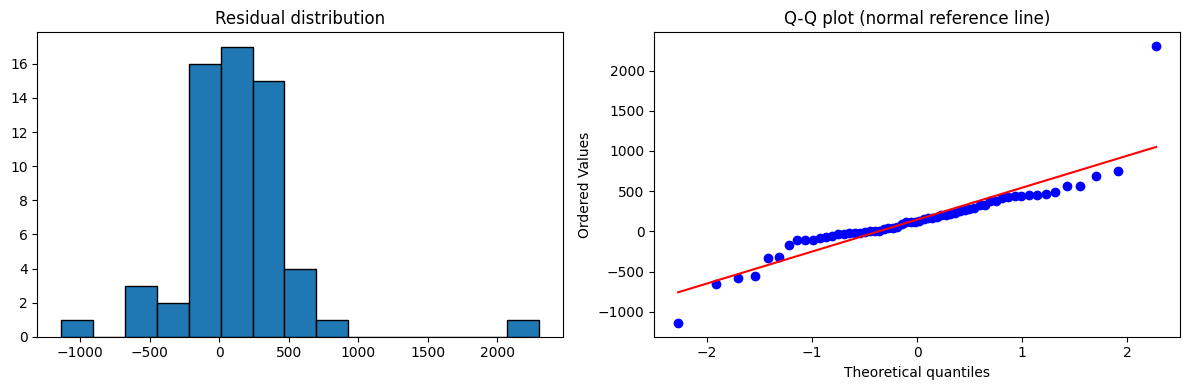

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fit2.resid, bins=15, edgecolor='black')
axes[0].set_title('Residual distribution')

stats.probplot(fit2.resid, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot (normal reference line)')

plt.tight_layout()
plt.show()

In [13]:
print("Model 1 (1,1,1)x(1,1,1,12): AIC =", round(fit.aic, 1), " BIC =", round(fit.bic, 1))
print("Model 2 (0,1,1)x(0,1,1,12): AIC =", round(fit2.aic, 1), " BIC =", round(fit2.bic, 1))
print("(Lower AIC/BIC = better fit relative to model complexity)")

Model 1 (1,1,1)x(1,1,1,12): AIC = 684.0  BIC = 693.3
Model 2 (0,1,1)x(0,1,1,12): AIC = 681.0  BIC = 686.6
(Lower AIC/BIC = better fit relative to model complexity)


In [14]:
# The single extreme outlier — find its date
print(residuals.sort_values(ascending=False).head(3))
print(fit2.resid.sort_values(ascending=False).head(3))

month
2021-01-01    2302.730000
2024-10-01     784.130642
2022-05-01     683.582779
dtype: float64
month
2021-01-01    2302.730000
2024-10-01     748.514633
2022-05-01     685.221858
dtype: float64


In [15]:
# Drop the first 13 months (1 regular diff + 12 seasonal diff) — these are burn-in, not real predictions
resid_z_trimmed = resid_z.iloc[13:]

print("Duplicate months:", resid_z_trimmed.index.duplicated().sum())
print(resid_z_trimmed.shape)

# Re-check normality on the trimmed residuals
stat, p_value = stats.shapiro(resid_z_trimmed)
print(f"\nShapiro-Wilk (trimmed): stat={stat:.3f}, p={p_value:.3f}")

print("\nTop 5 stress candidates (trimmed):")
print(resid_z_trimmed.sort_values().head(5))

Duplicate months: 0
(47,)

Shapiro-Wilk (trimmed): stat=0.972, p=0.314

Top 5 stress candidates (trimmed):
month
2025-02-01   -1.720088
2024-11-01   -1.628843
2025-10-01   -1.612119
2023-02-01   -1.138847
2025-09-01   -1.133886
dtype: float64


In [16]:
resid_z_trimmed.to_csv('sarima_residuals.csv')
files.download('sarima_residuals.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
df['value_cr'] = df['Value (In Cr.)'].astype(str).str.strip().str.replace(',', '', regex=False).astype(float)
df['volume_mn'] = df['Volume (In Mn.)'].astype(str).str.strip().str.replace(',', '', regex=False).astype(float)
df['month_parsed'] = pd.to_datetime(df['Month'], format='%B-%Y')

clean_2021on = df[['month_parsed', 'volume_mn', 'value_cr']].rename(columns={'month_parsed': 'month'})
clean_2021on = clean_2021on.sort_values('month').reset_index(drop=True)
clean_2021on = clean_2021on[clean_2021on['month'] >= '2021-01-01'].reset_index(drop=True)

print("Duplicate months:", clean_2021on['month'].duplicated().sum())
print(clean_2021on.shape)

Duplicate months: 0
(66, 3)


In [18]:
print(resid_z_trimmed.shape)
print(resid_z_trimmed.head())


(47,)
month
2022-02-01   -0.788977
2022-03-01    0.546050
2022-04-01    0.758939
2022-05-01    1.248359
2022-06-01   -0.410539
Freq: MS, dtype: float64


In [20]:
queuing_df = clean_2021on.copy()

queuing_df['days_in_month'] = queuing_df['month'].dt.days_in_month
queuing_df['seconds_in_month'] = queuing_df['days_in_month'] * 24 * 60 * 60

queuing_df['total_transactions'] = queuing_df['volume_mn'] * 1_000_000
queuing_df['lambda_avg_tps'] = queuing_df['total_transactions'] / queuing_df['seconds_in_month']

print(queuing_df[['month', 'volume_mn', 'days_in_month', 'lambda_avg_tps']].head(5))
print("\nLatest months:")
print(queuing_df[['month', 'volume_mn', 'lambda_avg_tps']].tail(6))
print("\nRange:", queuing_df['lambda_avg_tps'].min().round(2), "to", queuing_df['lambda_avg_tps'].max().round(2))

       month  volume_mn  days_in_month  lambda_avg_tps
0 2021-01-01    2302.73             31      859.740890
1 2021-02-01    2292.90             28      947.792659
2 2021-03-01    2731.68             31     1019.892473
3 2021-04-01    2641.06             30     1018.927469
4 2021-05-01    2539.57             31      948.166816

Latest months:
        month  volume_mn  lambda_avg_tps
60 2026-01-01   21703.44     8103.136201
61 2026-02-01   20394.18     8430.133929
62 2026-03-01   22641.11     8453.222073
63 2026-04-01   22346.80     8621.450617
64 2026-05-01   23201.93     8662.608274
65 2026-06-01   22716.07     8763.915895


AttributeError: 'float' object has no attribute 'round'

In [21]:
print("\nRange:", round(queuing_df['lambda_avg_tps'].min(), 2), "to", round(queuing_df['lambda_avg_tps'].max(), 2))


Range: 859.74 to 8763.92


In [22]:
mu_floor = queuing_df.loc[queuing_df['month']=='2025-04-01', 'lambda_avg_tps'].values[0]
print("Outage-anchored floor (April 2025):", round(mu_floor, 2))

Outage-anchored floor (April 2025): 6903.33


In [23]:
mu_low = mu_floor * 1.2
mu_high = mu_floor * 1.8

outage_months = pd.to_datetime(['2025-03-01', '2025-04-01'])
non_outage = queuing_df.loc[~queuing_df['month'].isin(outage_months)]
mu_peak_baseline = non_outage['lambda_avg_tps'].max()

print("Sensitivity low (1.2x floor):", round(mu_low, 2))
print("Sensitivity high (1.8x floor):", round(mu_high, 2))
print("Peak-throughput baseline (primary):", round(mu_peak_baseline, 2))

Sensitivity low (1.2x floor): 8283.99
Sensitivity high (1.8x floor): 12425.99
Peak-throughput baseline (primary): 8763.92


In [24]:
for mu_val, colname in [(mu_floor, 'rho_floor'), (mu_low, 'rho_sens_low'),
                          (mu_high, 'rho_sens_high'), (mu_peak_baseline, 'rho_peak_baseline')]:
    queuing_df[colname] = queuing_df['lambda_avg_tps'] / mu_val

for colname, mu_val, label in [('rho_floor', mu_floor, 'Outage-anchored floor'),
                                 ('rho_sens_low', mu_low, 'Sensitivity low'),
                                 ('rho_sens_high', mu_high, 'Sensitivity high'),
                                 ('rho_peak_baseline', mu_peak_baseline, 'Peak-throughput baseline')]:
    n_violations = (queuing_df[colname] >= 1).sum()
    print(f"{label} (μ={round(mu_val,2)}): {n_violations} months with ρ≥1 out of {len(queuing_df)}")

Outage-anchored floor (μ=6903.33): 15 months with ρ≥1 out of 66
Sensitivity low (μ=8283.99): 5 months with ρ≥1 out of 66
Sensitivity high (μ=12425.99): 0 months with ρ≥1 out of 66
Peak-throughput baseline (μ=8763.92): 1 months with ρ≥1 out of 66


In [25]:
queuing_df.to_csv('mm1_queuing_results.csv', index=False)
files.download('mm1_queuing_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 6 months before + 6 months after the disruption period, excluding Mar/Apr/May 2025 itself
local_window = queuing_df[
    (queuing_df['month'] >= '2024-09-01') & (queuing_df['month'] <= '2025-11-30') &
    (~queuing_df['month'].isin(pd.to_datetime(['2025-03-01', '2025-04-01', '2025-05-01'])))
].copy()

print("Local window months used for the trend fit:")
print(local_window[['month', 'rho_peak_baseline']])
print("\nNumber of months in local trend fit:", len(local_window))

Local window months used for the trend fit:
        month  rho_peak_baseline
44 2024-09-01           0.662163
45 2024-10-01           0.706547
46 2024-11-01           0.681545
47 2024-12-01           0.712726
48 2025-01-01           0.724058
49 2025-02-01           0.759666
53 2025-06-01           0.809780
54 2025-07-01           0.829367
55 2025-08-01           0.852387
56 2025-09-01           0.864297
57 2025-10-01           0.881893
58 2025-11-01           0.900991

Number of months in local trend fit: 12


In [31]:
local_window = local_window.reset_index(drop=True)
local_window['month_num'] = np.arange(len(local_window))

X = local_window[['month_num']].values
y = local_window['rho_peak_baseline'].values

reg = LinearRegression().fit(X, y)
r_squared = reg.score(X, y)
print("Local trend R-squared:", round(r_squared, 3))

disruption_months = queuing_df[queuing_df['month'].isin(pd.to_datetime(['2025-03-01', '2025-04-01', '2025-05-01']))].copy()
disruption_months['month_num'] = [6, 7, 8]

predicted_rho = reg.predict(disruption_months[['month_num']].values)
residual_std = np.std(y - reg.predict(X))

disruption_months['predicted_rho'] = predicted_rho
disruption_months['deviation_sd'] = (disruption_months['rho_peak_baseline'] - predicted_rho) / residual_std

print(disruption_months[['month', 'rho_peak_baseline', 'predicted_rho', 'deviation_sd']])

Local trend R-squared: 0.965
        month  rho_peak_baseline  predicted_rho  deviation_sd
50 2025-03-01           0.779674       0.793567     -0.925780
51 2025-04-01           0.787699       0.816465     -1.916918
52 2025-05-01           0.795691       0.839363     -2.910227


In [32]:
# Check: are we correctly capturing the real month-to-month gap, or does skipping Mar/Apr/May distort the fit?
print(local_window[['month', 'month_num']])

        month  month_num
0  2024-09-01          0
1  2024-10-01          1
2  2024-11-01          2
3  2024-12-01          3
4  2025-01-01          4
5  2025-02-01          5
6  2025-06-01          6
7  2025-07-01          7
8  2025-08-01          8
9  2025-09-01          9
10 2025-10-01         10
11 2025-11-01         11


In [33]:
# Use REAL time distance (months since a fixed anchor), not a bare sequential index
anchor = pd.Timestamp('2024-09-01')

local_window['month_num'] = ((local_window['month'].dt.year - anchor.year) * 12 +
                               (local_window['month'].dt.month - anchor.month))

X = local_window[['month_num']].values
y = local_window['rho_peak_baseline'].values

reg = LinearRegression().fit(X, y)
r_squared = reg.score(X, y)
print("Local trend R-squared:", round(r_squared, 3))

disruption_months = queuing_df[queuing_df['month'].isin(pd.to_datetime(['2025-03-01', '2025-04-01', '2025-05-01']))].copy()
disruption_months['month_num'] = ((disruption_months['month'].dt.year - anchor.year) * 12 +
                                    (disruption_months['month'].dt.month - anchor.month))

predicted_rho = reg.predict(disruption_months[['month_num']].values)
residual_std = np.std(y - reg.predict(X))

disruption_months['predicted_rho'] = predicted_rho
disruption_months['deviation_sd'] = (disruption_months['rho_peak_baseline'] - predicted_rho) / residual_std

print(disruption_months[['month', 'rho_peak_baseline', 'predicted_rho', 'deviation_sd']])

Local trend R-squared: 0.985
        month  rho_peak_baseline  predicted_rho  deviation_sd
50 2025-03-01           0.779674       0.765527      1.443306
51 2025-04-01           0.787699       0.782118      0.569305
52 2025-05-01           0.795691       0.798710     -0.308019


In [34]:
disruption_months.to_csv('mm1_local_trend_validation.csv', index=False)
files.download('mm1_local_trend_validation.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
full_ts = clean_2021on.set_index('month')['volume_mn'].asfreq('MS')

cutoff = '2025-06-01'
ts_backtest = full_ts.loc[:cutoff]
ts_actual_future = full_ts.loc['2025-07-01':'2026-06-01']

print("Backtest training data:", ts_backtest.index.min(), "to", ts_backtest.index.max(), f"({len(ts_backtest)} months)")
print("Actual future data to compare against:", ts_actual_future.index.min(), "to", ts_actual_future.index.max(), f"({len(ts_actual_future)} months)")

Backtest training data: 2021-01-01 00:00:00 to 2025-06-01 00:00:00 (54 months)
Actual future data to compare against: 2025-07-01 00:00:00 to 2026-06-01 00:00:00 (12 months)


In [36]:
backtest_model = SARIMAX(ts_backtest, order=(0,1,1), seasonal_order=(0,1,1,12))
backtest_fit = backtest_model.fit(disp=False)

forecast_future = backtest_fit.get_forecast(steps=12)
forecast_mean = forecast_future.predicted_mean

backtest_comparison = pd.DataFrame({
    'actual_volume': ts_actual_future,
    'forecast_volume': forecast_mean
})
backtest_comparison['abs_error_pct'] = (
    (backtest_comparison['forecast_volume'] - backtest_comparison['actual_volume']).abs()
    / backtest_comparison['actual_volume'] * 100
)

print(backtest_comparison)
print("\nMean absolute volume error:", round(backtest_comparison['abs_error_pct'].mean(), 2), "%")

            actual_volume  forecast_volume  abs_error_pct
2025-07-01       19467.95     18986.040662       2.475398
2025-08-01       20008.31     19499.454809       2.543219
2025-09-01       19633.43     19592.829968       0.206790
2025-10-01       20700.92     21206.959368       2.444526
2025-11-01       20466.98     20005.368714       2.255395
2025-12-01       21634.67     21300.615153       1.544072
2026-01-01       21703.44     21576.150784       0.586493
2026-02-01       20394.18     20595.503052       0.987159
2026-03-01       22641.11     22881.944381       1.063704
2026-04-01       22346.80     22448.008462       0.452899
2026-05-01       23201.93     23235.756182       0.145790
2026-06-01       22716.07     22939.915744       0.985407

Mean absolute volume error: 1.31 %


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


In [37]:
# Fair backtest mu: peak throughput using ONLY data available up to the cutoff (June 2025)
pre_cutoff_data = queuing_df[queuing_df['month'] <= cutoff]
mu_backtest = pre_cutoff_data['lambda_avg_tps'].max()
print("Backtest-fair mu (peak known as of July 2025):", round(mu_backtest, 2))

# Convert both actual and forecast volume into TPS, then rho, using this fair mu
backtest_comparison_reset = backtest_comparison.reset_index().rename(columns={'index': 'month'})
backtest_comparison_reset['days_in_month'] = backtest_comparison_reset['month'].dt.days_in_month
backtest_comparison_reset['seconds_in_month'] = backtest_comparison_reset['days_in_month'] * 24 * 60 * 60

backtest_comparison_reset['actual_lambda'] = (backtest_comparison_reset['actual_volume'] * 1_000_000) / backtest_comparison_reset['seconds_in_month']
backtest_comparison_reset['forecast_lambda'] = (backtest_comparison_reset['forecast_volume'] * 1_000_000) / backtest_comparison_reset['seconds_in_month']

backtest_comparison_reset['actual_rho'] = backtest_comparison_reset['actual_lambda'] / mu_backtest
backtest_comparison_reset['forecast_rho'] = backtest_comparison_reset['forecast_lambda'] / mu_backtest
backtest_comparison_reset['rho_abs_error'] = (backtest_comparison_reset['forecast_rho'] - backtest_comparison_reset['actual_rho']).abs()

print(backtest_comparison_reset[['month', 'actual_rho', 'forecast_rho', 'rho_abs_error']])
print("\nMean absolute rho error:", round(backtest_comparison_reset['rho_abs_error'].mean(), 4))
print("\nMonths where actual_rho >= 1:", (backtest_comparison_reset['actual_rho'] >= 1).sum())
print("Months where forecast_rho >= 1:", (backtest_comparison_reset['forecast_rho'] >= 1).sum())

Backtest-fair mu (peak known as of July 2025): 7096.84
        month  actual_rho  forecast_rho  rho_abs_error
0  2025-07-01    1.024188      0.998835       0.025353
1  2025-08-01    1.052616      1.025846       0.026770
2  2025-09-01    1.067324      1.065117       0.002207
3  2025-10-01    1.089053      1.115676       0.026622
4  2025-11-01    1.112638      1.087543       0.025094
5  2025-12-01    1.138177      1.120603       0.017574
6  2026-01-01    1.141795      1.135098       0.006697
7  2026-02-01    1.187871      1.199598       0.011726
8  2026-03-01    1.191125      1.203795       0.012670
9  2026-04-01    1.214829      1.220331       0.005502
10 2026-05-01    1.220629      1.222408       0.001780
11 2026-06-01    1.234904      1.247073       0.012169

Mean absolute rho error: 0.0145

Months where actual_rho >= 1: 12
Months where forecast_rho >= 1: 11


In [38]:
backtest_comparison_reset.to_csv('backtest_results.csv', index=False)
files.download('backtest_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
full_model = SARIMAX(full_ts, order=(0,1,1), seasonal_order=(0,1,1,12))
full_fit = full_model.fit(disp=False)

forward_forecast = full_fit.get_forecast(steps=12)
forward_mean = forward_forecast.predicted_mean

forward_df = forward_mean.reset_index()
forward_df.columns = ['month', 'forecast_volume_mn']

forward_df['days_in_month'] = forward_df['month'].dt.days_in_month
forward_df['seconds_in_month'] = forward_df['days_in_month'] * 24 * 60 * 60
forward_df['forecast_lambda'] = (forward_df['forecast_volume_mn'] * 1_000_000) / forward_df['seconds_in_month']

# Using the two most relevant mu scenarios: peak-baseline (primary) and sensitivity-high (generous)
forward_df['rho_peak_baseline'] = forward_df['forecast_lambda'] / mu_peak_baseline
forward_df['rho_sens_high'] = forward_df['forecast_lambda'] / mu_high

print(forward_df[['month', 'forecast_volume_mn', 'forecast_lambda', 'rho_peak_baseline', 'rho_sens_high']])

        month  forecast_volume_mn  forecast_lambda  rho_peak_baseline  \
0  2026-07-01        23844.759325      8902.613249           1.015826   
1  2026-08-01        24384.641799      9104.182273           1.038826   
2  2026-09-01        24034.377593      9272.522220           1.058034   
3  2026-10-01        25125.856025      9380.919962           1.070403   
4  2026-11-01        24847.028360      9586.044892           1.093808   
5  2026-12-01        26017.686367      9713.891266           1.108396   
6  2027-01-01        26097.038102      9743.517810           1.111777   
7  2027-02-01        24813.128863     10256.749695           1.170339   
8  2027-03-01        27054.604057     10101.031981           1.152571   
9  2027-04-01        26754.918400     10322.113580           1.177797   
10 2027-05-01        27605.955647     10306.883082           1.176059   
11 2027-06-01        27131.674396     10467.466974           1.194382   

    rho_sens_high  
0        0.716451  
1        0

In [40]:
# Target: rho <= 0.9 at every point in the forward forecast (worst month sets the requirement)
peak_lambda_forecast = forward_df['forecast_lambda'].max()

# Capacity needed under each scenario, to keep the WORST forecast month at rho=0.9
mu_needed_baseline_scenario = peak_lambda_forecast / 0.9
mu_needed_generous_scenario = peak_lambda_forecast / 0.9  # same lambda, compared against each current mu

growth_needed_baseline = ((mu_needed_baseline_scenario - mu_peak_baseline) / mu_peak_baseline) * 100
growth_needed_generous = ((mu_needed_generous_scenario - mu_high) / mu_high) * 100

print("Peak forecast lambda (worst month, Jul26-Jun27):", round(peak_lambda_forecast, 2))
print("\nUnder peak-baseline mu (current =", round(mu_peak_baseline,2), "):")
print("  Capacity needed for rho<=0.9:", round(mu_needed_baseline_scenario, 2))
print("  Growth required:", round(growth_needed_baseline, 1), "%")

print("\nUnder generous sensitivity-high mu (current =", round(mu_high,2), "):")
print("  Capacity needed for rho<=0.9:", round(mu_needed_generous_scenario, 2))
print("  Growth required:", round(growth_needed_generous, 1), "%")

Peak forecast lambda (worst month, Jul26-Jun27): 10467.47

Under peak-baseline mu (current = 8763.92 ):
  Capacity needed for rho<=0.9: 11630.52
  Growth required: 32.7 %

Under generous sensitivity-high mu (current = 12425.99 ):
  Capacity needed for rho<=0.9: 11630.52
  Growth required: -6.4 %


In [41]:
forward_df.to_csv('rho_forecast_stress_onset.csv', index=False)
files.download('rho_forecast_stress_onset.csv')

capacity_summary = pd.DataFrame({
    'scenario': ['peak_baseline (tight)', 'sensitivity_high (generous)'],
    'current_mu': [mu_peak_baseline, mu_high],
    'mu_needed_for_rho_0.9': [mu_needed_baseline_scenario, mu_needed_generous_scenario],
    'growth_pct_required': [growth_needed_baseline, growth_needed_generous]
})
capacity_summary.to_csv('capacity_growth_recommendation.csv', index=False)
files.download('capacity_growth_recommendation.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
residual_std_corrected = np.std(y - reg.predict(X), ddof=1)  # sample std, matches the more defensible convention

disruption_months['predicted_rho'] = predicted_rho
disruption_months['deviation_sd'] = (disruption_months['rho_peak_baseline'] - predicted_rho) / residual_std_corrected

print(disruption_months[['month', 'rho_peak_baseline', 'predicted_rho', 'deviation_sd']])

disruption_months.to_csv('mm1_local_trend_validation.csv', index=False)
files.download('mm1_local_trend_validation.csv')

        month  rho_peak_baseline  predicted_rho  deviation_sd
50 2025-03-01           0.779674       0.765527      1.381861
51 2025-04-01           0.787699       0.782118      0.545068
52 2025-05-01           0.795691       0.798710     -0.294906


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
# Rolling-origin cross-validation: each fold trains on an expanding window,
# tests on the next 6 months, then slides forward
fold_results = []

# Start with at least 36 months of training data (3 years), leave room for 6-month test windows
min_train_size = 36
step = 6  # slide forward 6 months each fold, same size as our original test window

fold_num = 1
start = min_train_size
while start + step <= len(full_ts):
    train_fold = full_ts.iloc[:start]
    test_fold = full_ts.iloc[start:start+step]

    model_fold = SARIMAX(train_fold, order=(0,1,1), seasonal_order=(0,1,1,12))
    fit_fold = model_fold.fit(disp=False)
    forecast_fold = fit_fold.forecast(steps=step)

    mape_fold = (np.abs(forecast_fold.values - test_fold.values) / test_fold.values * 100).mean()

    fold_results.append({
        'fold': fold_num,
        'train_months': len(train_fold),
        'train_end': train_fold.index[-1].strftime('%Y-%m'),
        'test_start': test_fold.index[0].strftime('%Y-%m'),
        'test_end': test_fold.index[-1].strftime('%Y-%m'),
        'mape_pct': round(mape_fold, 2)
    })

    fold_num += 1
    start += step

fold_df = pd.DataFrame(fold_results)
print(fold_df)
print("\nMean MAPE across all folds:", round(fold_df['mape_pct'].mean(), 2), "%")
print("Std dev across folds:", round(fold_df['mape_pct'].std(), 2), "%")
print("Min:", round(fold_df['mape_pct'].min(), 2), "% | Max:", round(fold_df['mape_pct'].max(), 2), "%")

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting season

   fold  train_months train_end test_start test_end  mape_pct
0     1            36   2023-12    2024-01  2024-06      2.89
1     2            42   2024-06    2024-07  2024-12      1.52
2     3            48   2024-12    2025-01  2025-06      1.38
3     4            54   2025-06    2025-07  2025-12      1.91
4     5            60   2025-12    2026-01  2026-06      1.69

Mean MAPE across all folds: 1.88 %
Std dev across folds: 0.6 %
Min: 1.38 % | Max: 2.89 %


In [46]:
fold_df.to_csv('kfold_cross_validation_results.csv', index=False)
files.download('kfold_cross_validation_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

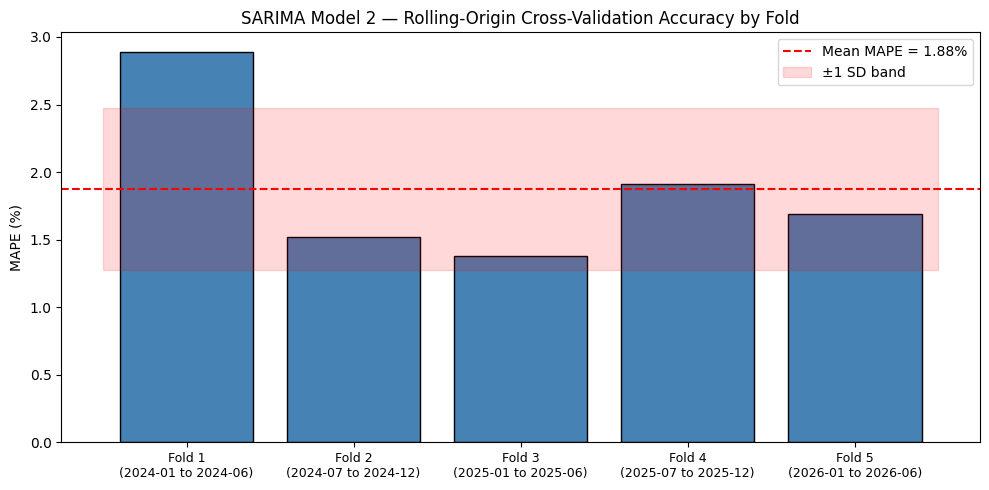

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(fold_df['fold'], fold_df['mape_pct'], color='steelblue', edgecolor='black')
ax.axhline(fold_df['mape_pct'].mean(), color='red', linestyle='--', label=f"Mean MAPE = {fold_df['mape_pct'].mean():.2f}%")
ax.fill_between([0.5, 5.5],
                 fold_df['mape_pct'].mean() - fold_df['mape_pct'].std(),
                 fold_df['mape_pct'].mean() + fold_df['mape_pct'].std(),
                 alpha=0.15, color='red', label='±1 SD band')
ax.set_xticks(fold_df['fold'])
ax.set_xticklabels([f"Fold {r.fold}\n({r.test_start} to {r.test_end})" for r in fold_df.itertuples()], fontsize=9)
ax.set_ylabel('MAPE (%)')
ax.set_title('SARIMA Model 2 — Rolling-Origin Cross-Validation Accuracy by Fold')
ax.legend()
plt.tight_layout()
plt.savefig('kfold_comparison_chart.png', dpi=200)
plt.show()

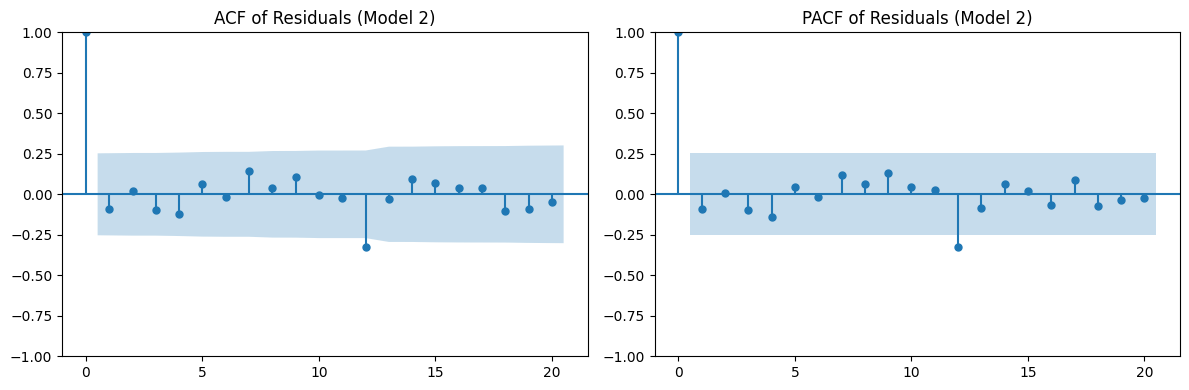

In [48]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(fit2.resid, lags=20, ax=axes[0], title='ACF of Residuals (Model 2)')
plot_pacf(fit2.resid, lags=20, ax=axes[1], title='PACF of Residuals (Model 2)')
plt.tight_layout()
plt.savefig('acf_pacf_diagnostics.png', dpi=200)
plt.show()

In [49]:
files.download('kfold_comparison_chart.png')
files.download('acf_pacf_diagnostics.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>